In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [3]:
datos_penguins = pd.read_csv('../../data/raw/penguins.csv')

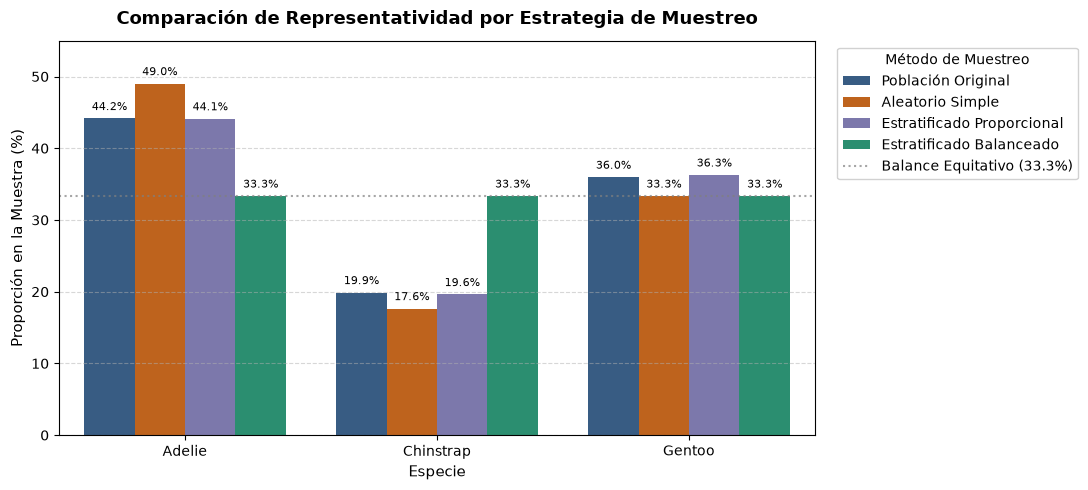

Composición porcentual (%) por estrategia:
  Especie  Población Original  Aleatorio Simple  Estratificado Proporcional  Estratificado Balanceado
   Adelie           44.152047         49.019608                   44.117647                 33.333333
Chinstrap           19.883041         17.647059                   19.607843                 33.333333
   Gentoo           35.964912         33.333333                   36.274510                 33.333333


In [4]:

# 1. Preparación de datos limpios
df_clean = datos_penguins.dropna(subset=['species', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']).copy()
N_total = len(df_clean)

# Fracción objetivo para la muestra (ej. 30% del dataset)
fraccion = 0.30
n_muestra = int(N_total * fraccion)

# -------------------------------------------------------------
# 2. Estrategias de Muestreo
# -------------------------------------------------------------

# A. Muestreo Aleatorio Simple (SRS)
df_srs = df_clean.sample(n=n_muestra, random_state=42)

# B. Muestreo Estratificado Proporcional (conserva proporciones poblacionales)
df_strat_prop, _ = train_test_split(
    df_clean,
    train_size=fraccion,
    stratify=df_clean['species'],
    random_state=42
)

# C. Muestreo Estratificado Balanceado (mismo tamaño por clase)
# n por clase = total muestra / cantidad de especies
n_por_clase = n_muestra // df_clean['species'].nunique()
df_strat_bal = df_clean.groupby('species', group_keys=False).sample(n=n_por_clase, random_state=42)

# -------------------------------------------------------------
# 3. Cálculo de proporciones relativas (%)
# -------------------------------------------------------------
comp_df = pd.DataFrame({
    'Población Original': df_clean['species'].value_counts(normalize=True) * 100,
    'Aleatorio Simple': df_srs['species'].value_counts(normalize=True) * 100,
    'Estratificado Proporcional': df_strat_prop['species'].value_counts(normalize=True) * 100,
    'Estratificado Balanceado': df_strat_bal['species'].value_counts(normalize=True) * 100
}).reset_index()

comp_df.rename(columns={'species': 'Especie'}, inplace=True)
comp_melted = comp_df.melt(id_vars='Especie', var_name='Estrategia', value_name='Porcentaje')

# -------------------------------------------------------------
# 4. Visualización Gráfica
# -------------------------------------------------------------
plt.figure(figsize=(11, 5))
paleta_estrategias = ['#2b5c8f', '#d95f02', '#7570b3', '#1b9e77']

ax = sns.barplot(
    data=comp_melted,
    x='Especie',
    y='Porcentaje',
    hue='Estrategia',
    palette=paleta_estrategias
)

# Línea de referencia para el balance perfecto (33.33%)
plt.axhline(100 / 3, color='gray', linestyle=':', alpha=0.7, label='Balance Equitativo (33.3%)')

plt.title("Comparación de Representatividad por Estrategia de Muestreo", fontsize=13, weight='bold', pad=12)
plt.ylabel("Proporción en la Muestra (%)", fontsize=11)
plt.xlabel("Especie", fontsize=11)
plt.ylim(0, 55)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Método de Muestreo', bbox_to_anchor=(1.02, 1), loc='upper left', framealpha=0.9)

# Anotar valores sobre las barras
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h + 0.8),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Mostrar tabla numérica explícita
print("Composición porcentual (%) por estrategia:")
print(comp_df.to_string(index=False))